# Gaussian puff — parameter estimation of a constant emission rate

Given a time-series of concentration observations at a handful of downwind sensors, we invert the puff forward model to recover the source emission rate Q. The setup closely parallels the plume parameter-estimation notebook, but the puff model's time-axis means each observation carries its own evaluation time — the NUTS posterior absorbs both spatial variation and the puff-cadence structure of the field.

See [00_gaussian_puff_derivation.md](00_gaussian_puff_derivation.md) for the forward model and `plume_simulation.gauss_puff.inference` for the NumPyro code.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import numpyro

from plume_simulation.gauss_puff import (
    infer_emission_rate,
    simulate_puff,
)

numpyro.set_host_device_count(1)

## 1. Generate synthetic observations

Set a ground-truth emission rate (0.12 kg/s), run the forward model, sample at four downwind receptors at six time steps, and add Gaussian noise. This is the "observe the truth through a noisy instrument" setup that motivates the inverse problem.

In [2]:
true_Q = 0.12
source = (0.0, 0.0, 2.0)
t_end = 180.0
n_t = 61
time_array = np.linspace(0.0, t_end, n_t, dtype=np.float32)
wind_speed = np.full(n_t, 5.0, dtype=np.float32)
wind_direction = np.full(n_t, 270.0, dtype=np.float32)
release_frequency = 1.0
stability = "C"

ds_truth = simulate_puff(
    emission_rate=true_Q,
    source_location=source,
    wind_speed=wind_speed,
    wind_direction=wind_direction,
    stability_class=stability,
    domain_x=(100.0, 700.0, 61),
    domain_y=(-40.0, 40.0, 21),
    domain_z=(0.0, 10.0, 6),
    time_array=time_array,
    release_frequency=release_frequency,
)

# Four receptors on a downwind transect at y=0, z=1 m.
receptor_x = np.array([200.0, 300.0, 450.0, 600.0], dtype=np.float32)
receptor_y = np.zeros_like(receptor_x)
receptor_z = np.full_like(receptor_x, 1.0)

# Observe at six times equally spaced in the "saturated" phase of the field.
obs_times = np.array([60.0, 90.0, 120.0, 150.0, 170.0, 180.0], dtype=np.float32)

rng = np.random.default_rng(0)
noise_std = 5e-8
obs_list = []
coord_x = []
coord_y = []
coord_z = []
t_list = []
for t_k in obs_times:
    for x_r, y_r, z_r in zip(receptor_x, receptor_y, receptor_z):
        clean = float(
            ds_truth["concentration"]
            .sel(time=t_k, method="nearest")
            .sel(x=x_r, method="nearest")
            .sel(y=y_r, method="nearest")
            .sel(z=z_r, method="nearest")
        )
        obs_list.append(clean + float(rng.normal(0.0, noise_std)))
        coord_x.append(float(x_r))
        coord_y.append(float(y_r))
        coord_z.append(float(z_r))
        t_list.append(float(t_k))

observations = np.asarray(obs_list, dtype=np.float32)
obs_coords = (
    np.asarray(coord_x, dtype=np.float32),
    np.asarray(coord_y, dtype=np.float32),
    np.asarray(coord_z, dtype=np.float32),
)
obs_times_full = np.asarray(t_list, dtype=np.float32)

Plot the observed concentration traces alongside the ground-truth field at one receptor to visualise SNR.

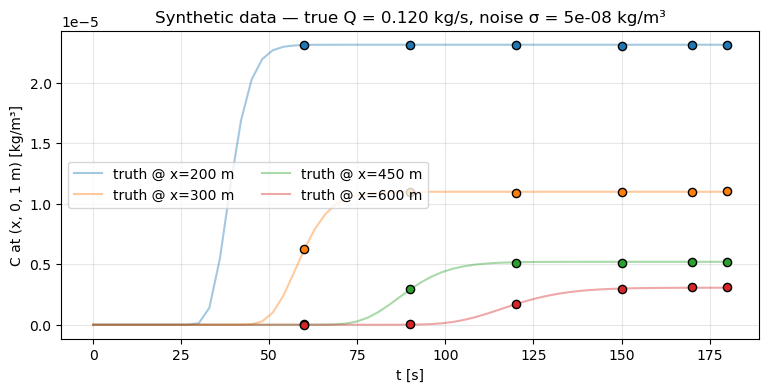

In [3]:
fig, ax = plt.subplots(figsize=(9, 4))
for x_r in receptor_x:
    truth_curve = (
        ds_truth["concentration"]
        .sel(x=x_r, method="nearest")
        .sel(y=0.0, method="nearest")
        .sel(z=1.0, method="nearest")
    )
    ax.plot(ds_truth["time"], truth_curve, alpha=0.4, label=f"truth @ x={x_r:.0f} m")

mask_x = np.isin(obs_coords[0], receptor_x)
for j, x_r in enumerate(receptor_x):
    sel = obs_coords[0] == x_r
    ax.scatter(obs_times_full[sel], observations[sel],
               color=f"C{j}", s=35, edgecolors="k", zorder=3)
ax.set_xlabel("t [s]")
ax.set_ylabel("C at (x, 0, 1 m) [kg/m³]")
ax.set_title(f"Synthetic data — true Q = {true_Q:.3f} kg/s, noise σ = {noise_std:g} kg/m³")
ax.grid(alpha=0.3)
ax.legend(ncols=2)
plt.show()

## 2. NUTS inference with a fixed stability class

LogNormal prior on Q with mean 0.1 and std 0.08 (covers both under- and overestimate scenarios). HalfNormal prior on background. NUTS handles the continuous parameters directly.

In [4]:
samples = infer_emission_rate(
    observations=observations,
    observation_coords=obs_coords,
    observation_times=obs_times_full,
    source_location=source,
    wind_times=time_array,
    wind_speed=wind_speed,
    wind_direction=wind_direction,
    release_frequency=release_frequency,
    t_start=0.0,
    t_end=float(t_end),
    stability_class=stability,
    prior_mean=0.10,
    prior_std=0.08,
    obs_noise_std=noise_std,
    num_warmup=300,
    num_samples=600,
    num_chains=1,
    seed=0,
    progress_bar=False,
)
q = samples["emission_rate"]
print(f"Posterior Q: mean = {q.mean():.4f} kg/s, std = {q.std():.4f}")
print(f"             90% CI = [{np.quantile(q, 0.05):.4f}, {np.quantile(q, 0.95):.4f}]")
print(f"True Q: {true_Q}")

Posterior Q: mean = 0.1187 kg/s, std = 0.0001
             90% CI = [0.1185, 0.1189]
True Q: 0.12


### Posterior over Q

/tmp/ipykernel_72604/287772686.py:14: RuntimeWarning: divide by zero encountered in divide
  1.0 / (q_grid * sigma_log * np.sqrt(2 * np.pi))


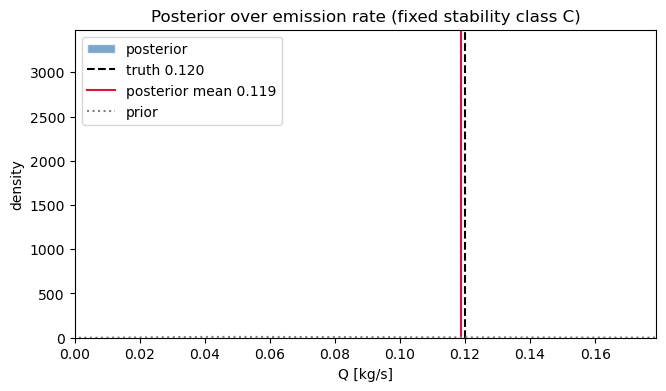

In [5]:
fig, ax = plt.subplots(figsize=(7.5, 4))
ax.hist(q, bins=40, density=True, alpha=0.7, color="steelblue",
        edgecolor="w", label="posterior")
ax.axvline(true_Q, color="k", linestyle="--", label=f"truth {true_Q:.3f}")
ax.axvline(float(q.mean()), color="crimson", linestyle="-",
           label=f"posterior mean {float(q.mean()):.3f}")
# Overlay the prior for reference.
prior_mean, prior_std = 0.10, 0.08
q_grid = np.linspace(0, 0.5, 400)
cv_sq = (prior_std / prior_mean) ** 2
sigma_log = np.sqrt(np.log1p(cv_sq))
mu_log = np.log(prior_mean) - 0.5 * sigma_log**2
lognorm_pdf = (
    1.0 / (q_grid * sigma_log * np.sqrt(2 * np.pi))
    * np.exp(-0.5 * ((np.log(np.maximum(q_grid, 1e-9)) - mu_log) / sigma_log) ** 2)
)
ax.plot(q_grid, lognorm_pdf, color="grey", linestyle=":", label="prior")
ax.set_xlim(0, min(0.4, q.max() * 1.5))
ax.set_xlabel("Q [kg/s]")
ax.set_ylabel("density")
ax.set_title("Posterior over emission rate (fixed stability class C)")
ax.legend()
plt.show()

## 3. Posterior-predictive check

Re-run the forward model at each posterior draw, take the mean and 90% interval, and overlay on the observations. If the bands cover the observations and the posterior mean tracks the trend, the model has captured the data-generating process.

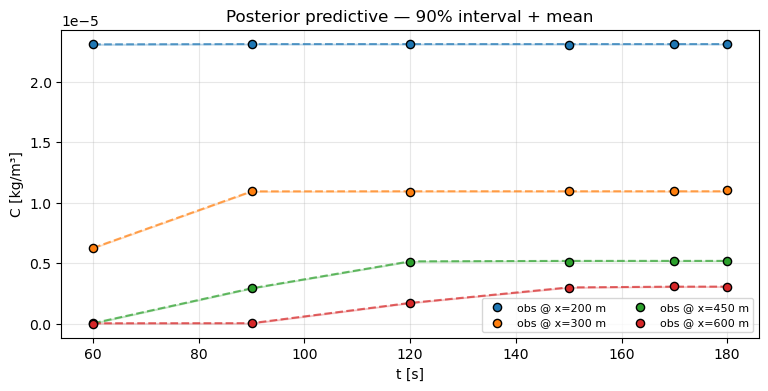

In [6]:
from plume_simulation.gauss_puff import (
    WindSchedule,
    make_release_times,
    frequency_to_release_interval,
)
from plume_simulation.gauss_puff.inference import _predict_observations
from plume_simulation.gauss_puff.dispersion import get_dispersion_scheme

scheme_params_dict, dispersion_fn = get_dispersion_scheme("pg")
dispersion_params = scheme_params_dict[stability]
schedule = WindSchedule.from_speed_direction(time_array, wind_speed, wind_direction)
release_times = make_release_times(0.0, float(t_end), release_frequency)
release_interval = frequency_to_release_interval(release_frequency)

import jax.numpy as jnp


def predict(Q_val, background_val):
    puff_mass = Q_val * release_interval * jnp.ones_like(release_times)
    pred = _predict_observations(
        puff_mass,
        release_times,
        tuple(jnp.asarray(c) for c in obs_coords),
        jnp.asarray(obs_times_full),
        source,
        schedule,
        dispersion_params,
        dispersion_fn,
    )
    return pred + background_val


subset = np.random.default_rng(0).choice(q.size, size=80, replace=False)
pred_draws = np.stack(
    [np.asarray(predict(q[i], samples["background"][i])) for i in subset]
)

fig, ax = plt.subplots(figsize=(9, 4))
for j, x_r in enumerate(receptor_x):
    sel = obs_coords[0] == x_r
    ax.scatter(obs_times_full[sel], observations[sel], color=f"C{j}",
               s=35, edgecolors="k", zorder=3, label=f"obs @ x={x_r:.0f} m")
    lo = np.quantile(pred_draws[:, sel], 0.05, axis=0)
    hi = np.quantile(pred_draws[:, sel], 0.95, axis=0)
    mean = pred_draws[:, sel].mean(axis=0)
    ax.fill_between(obs_times_full[sel], lo, hi, color=f"C{j}", alpha=0.2)
    ax.plot(obs_times_full[sel], mean, color=f"C{j}", linestyle="--", alpha=0.7)
ax.set_xlabel("t [s]")
ax.set_ylabel("C [kg/m³]")
ax.set_title("Posterior predictive — 90% interval + mean")
ax.grid(alpha=0.3)
ax.legend(ncols=2, fontsize=8)
plt.show()

## 4. Trace diagnostics

Posterior sample traces and autocorrelation for the two continuous latents. Look for adequate mixing (no long flat segments) and fast decay of autocorrelation.

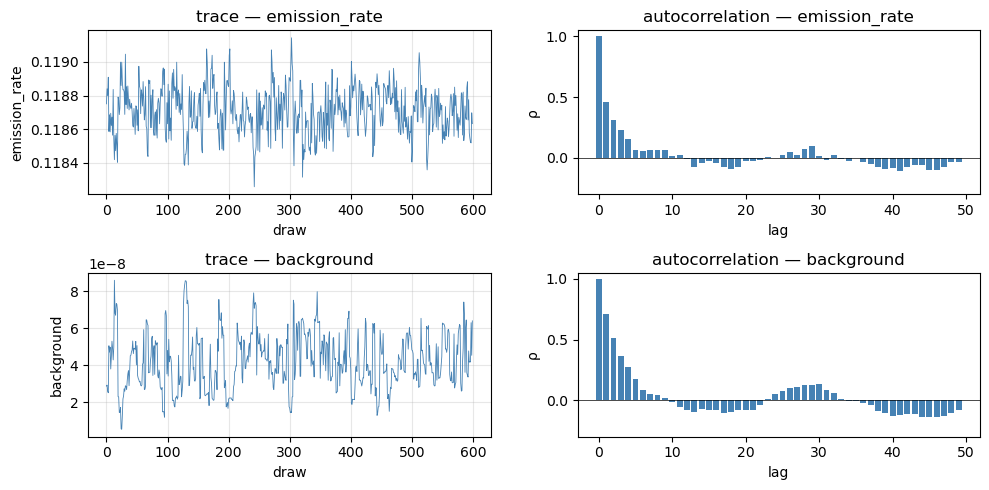

Posterior summary:
  emission_rate: mean=0.1187, std=0.0001, 5th=0.1185, 95th=0.1189
  background:    mean=4.24e-08, std=1.50e-08


In [7]:
fig, axes = plt.subplots(2, 2, figsize=(10, 5))
for row, (name, values) in enumerate(
    [("emission_rate", q), ("background", samples["background"])]
):
    axes[row, 0].plot(values, lw=0.6, color="steelblue")
    axes[row, 0].set_title(f"trace — {name}")
    axes[row, 0].set_xlabel("draw")
    axes[row, 0].set_ylabel(name)
    axes[row, 0].grid(alpha=0.3)

    # Empirical autocorrelation up to lag 50.
    vc = values - values.mean()
    nlags = 50
    acf = np.array(
        [float(np.dot(vc[: len(vc) - k], vc[k:]) / np.dot(vc, vc)) for k in range(nlags)]
    )
    axes[row, 1].bar(np.arange(nlags), acf, color="steelblue", width=0.8)
    axes[row, 1].axhline(0.0, color="k", lw=0.5)
    axes[row, 1].set_title(f"autocorrelation — {name}")
    axes[row, 1].set_xlabel("lag")
    axes[row, 1].set_ylabel("ρ")
    axes[row, 1].set_ylim(-0.3, 1.05)
plt.tight_layout()
plt.show()

print(f"Posterior summary:")
print(f"  emission_rate: mean={q.mean():.4f}, std={q.std():.4f}, "
      f"5th={np.quantile(q, 0.05):.4f}, 95th={np.quantile(q, 0.95):.4f}")
bg = samples["background"]
print(f"  background:    mean={bg.mean():.2e}, std={bg.std():.2e}")

## What next?

- [03_puff_state_estimation.ipynb](03_puff_state_estimation.ipynb) — when Q is *time-varying*, a constant-Q posterior is mis-specified. The state-estimation notebook drops the constant assumption via a random-walk prior on `Q_i`.